# Classification

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# 2진 분류(binary-calss classification) 문제

* breast cancer 데이터에서 Malignant/Benign 분류
* KNN classifier
* Logistic regression
* SGD classifier

## 데이터 셋 준비

In [2]:
bc=datasets.load_breast_cancer()

In [3]:
bc.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
x= bc.data # 특성 배열(2d array)
y=bc.target # 타겟 배열(1d array)

In [5]:
x.shape , y.shape

((569, 30), (569,))

In [6]:
pd.Series(y).value_counts() # 0은 Malignant(암), 1은 Benign(음성)

,count
1,357
0,212


TODO: 탐색적 데이터 분석(데이터 시각화: 빈도 막대 그래프, 히스토그램, 산점도, pairplot)

In [112]:
bc.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
cancer_df=pd.DataFrame(x,columns=bc.feature_names)
cancer_df['target']=y
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
np.unique(cancer_df.target,return_counts=True)

(array([0, 1]), array([212, 357]))

In [9]:
cancer_df.target=np.where(cancer_df.target==0,'Malignant','Benign')


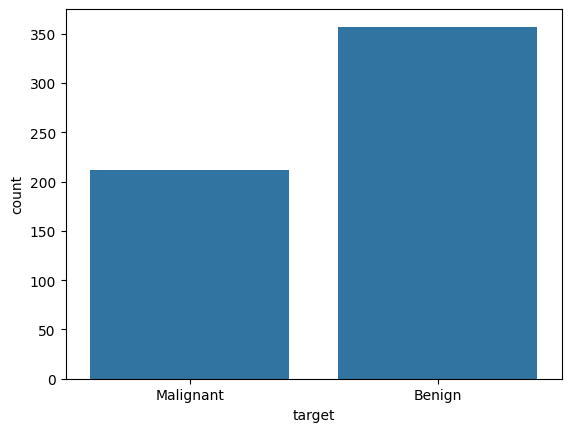

In [10]:
sns.countplot(x='target',data=cancer_df)
plt.show()

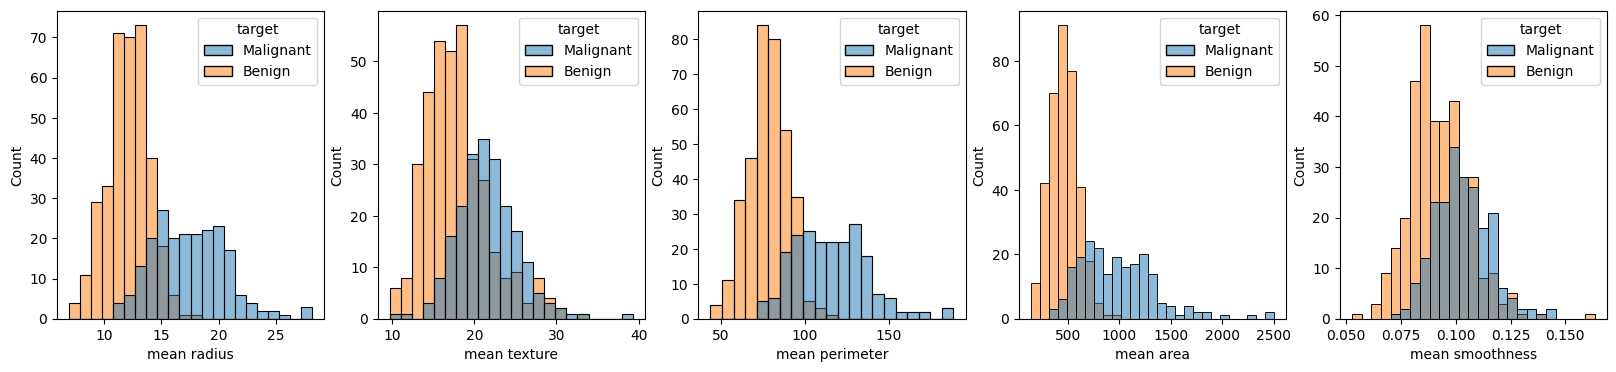

In [11]:
fig,axes=plt.subplots(1,5,figsize=(20,4))

for i,col  in enumerate(cancer_df.columns[:5]):
  sns.histplot(x=col,data=cancer_df,hue='target',ax=axes[i])
plt.show()

In [12]:
sub_df=cancer_df.iloc[:,[0,1,2,3,4,30]]
sub_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,target
0,17.99,10.38,122.80,1001.0,0.11840,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,Malignant
3,11.42,20.38,77.58,386.1,0.14250,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,Malignant
...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,Malignant
565,20.13,28.25,131.20,1261.0,0.09780,Malignant
566,16.60,28.08,108.30,858.1,0.08455,Malignant
567,20.60,29.33,140.10,1265.0,0.11780,Malignant


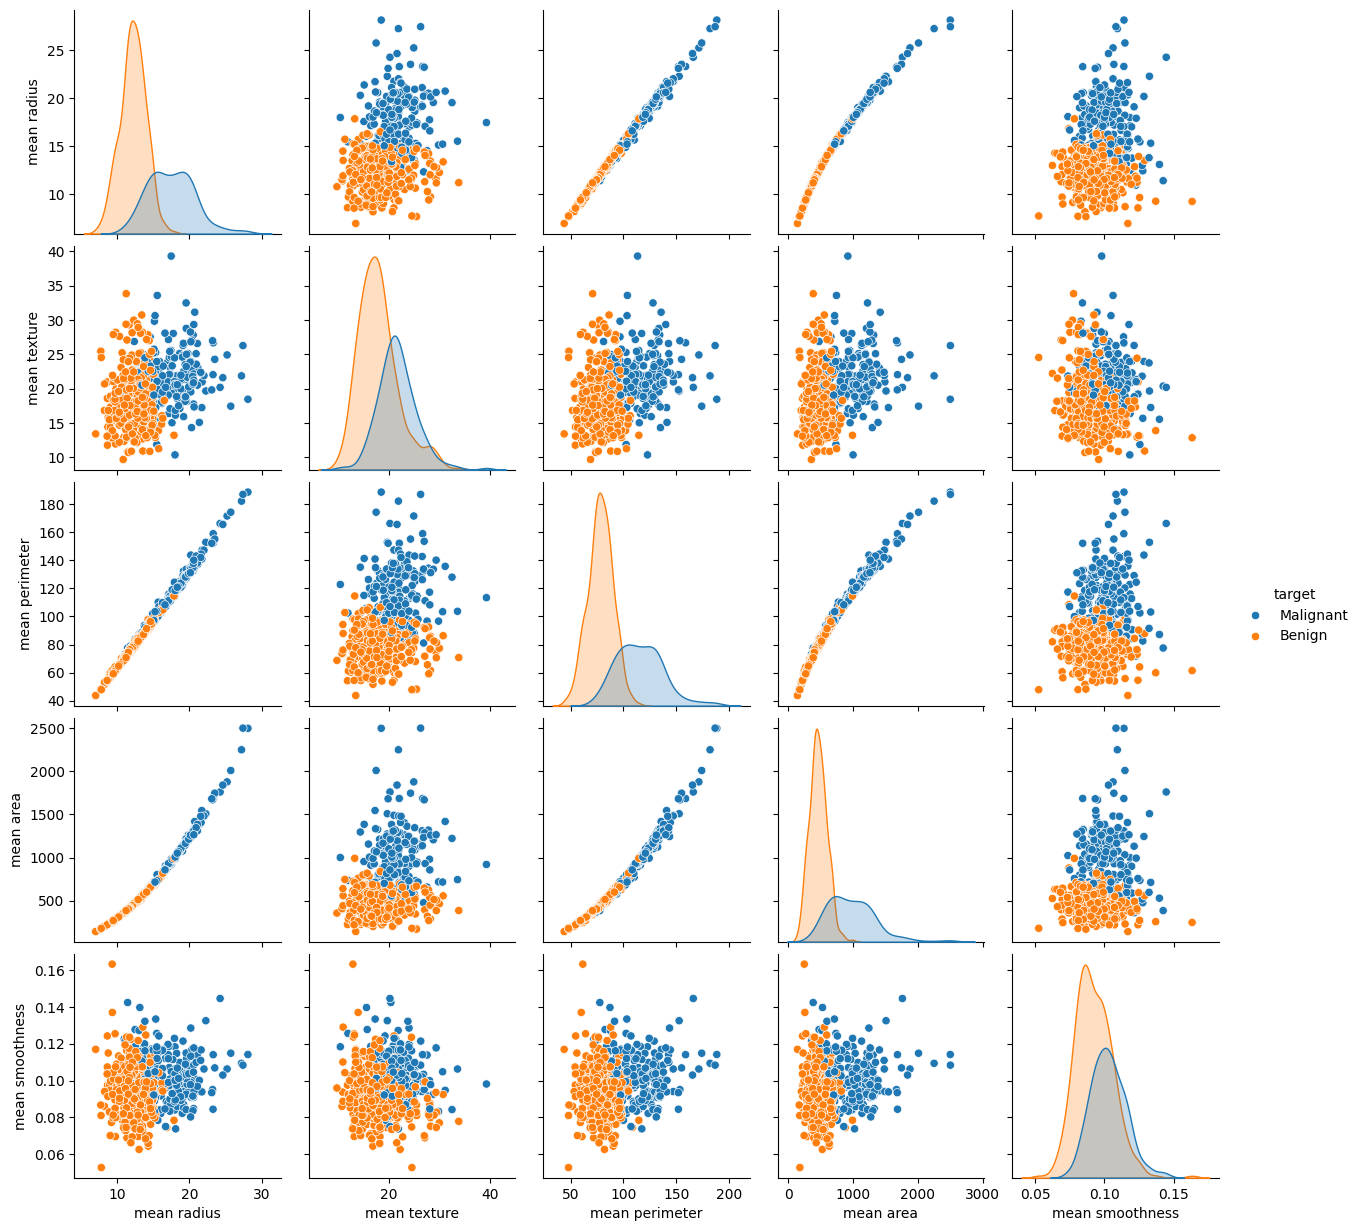

In [13]:
sns.pairplot(sub_df,hue='target')
plt.show()

## 훈련 셋, 테스트 셋 나누기

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42,stratify=y)

## KNN

In [15]:
# ML 모델
pipe=Pipeline(steps=[('scaler',StandardScaler()),('knn',KNeighborsClassifier())])
# knn=KNeighborsClassifier() # n_neighbors=5KNN 모델 생성

In [16]:
# ML 모델 훈련
pipe.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [17]:
trainpred=pipe.predict(x_train)
trainpred # 훈련셋 예측값

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,

In [18]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[161,   9],
       [  3, 282]])

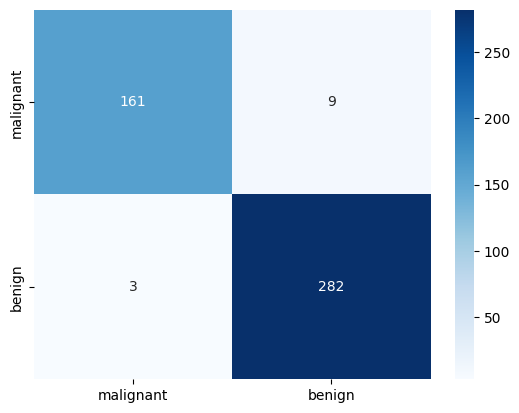

In [19]:
sns.heatmap(cmtrain,annot=True,cmap='Blues',fmt='d',xticklabels=bc.target_names,yticklabels=bc.target_names)
plt.show() # fmt는 엑스퍼넨셜표기 x

In [20]:
print(classification_report(y_train,trainpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96       170
      benign       0.97      0.99      0.98       285

    accuracy                           0.97       455
   macro avg       0.98      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455



In [21]:
testpred=pipe.predict(x_test)
testpred # 테스트 셋 예측값

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [22]:
print(classification_report(y_test,testpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## precision(정밀도)-recall(재현율) 곡선

*   정밀도(precision)와 재현율(recall)은 trade-off 관계가 있음.
    *   같은 정확도(accuracy)에서 정밀도가 좋아지면 재현율이 나빠지고, 재현율이 좋아지면 정밀도가 나빠짐.
*   정밀도를 y축으로, 재현율을 x축으로 설정해서 trade-off 관계를 나타낸 그래프.

In [104]:
# PrecisionRecallDisplay.from_estimator(knn,x_test,y_test)
# plt.show()

NameError: name 'knn' is not defined

## Logistic Regression

TODO: Pipeline(PolynomialFeature > StandardScaler > LogisticRegression)

In [23]:
# Pipeline(PolynomialFeatures > StandardScaler > LogisticRegerssion)
pipe=Pipeline(steps=[('poly',PolynomialFeatures()),('scaler',StandardScaler()),('logi',LogisticRegression(random_state=42))])

In [24]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('logi', LogisticRegression(random_state=42))])

In [25]:
trainpred=pipe.predict(x_train)

In [26]:
cmtrain=confusion_matrix(y_train,trainpred)


In [27]:
print(classification_report(y_train,trainpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.99      0.98      0.99       170
      benign       0.99      1.00      0.99       285

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455



In [28]:
testpred=pipe.predict(x_test)

In [29]:
cmtest=confusion_matrix(y_test,testpred)

In [30]:
print(classification_report(y_test,testpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [31]:
# # Pipeline(PolynomialFeatures > StandardScaler > LogisticRegerssion)
# pipe=Pipeline(steps=[('poly',PolynomialFeatures()),('scaler',StandardScaler()),('logi',LogisticRegression(random_state=42))])

# Logistic Regression ML  모델생성
logit = LogisticRegression(random_state=42,max_iter=10000)

In [32]:
#ML 모델 훈련
logit.fit(x_train,y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [33]:
trainpred=logit.predict(x_train)
trainpred # 훈련 셋 예측값

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,

In [34]:
cmtrain=confusion_matrix(y_train,trainpred)

In [35]:
print(classification_report(y_train,trainpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94       170
      benign       0.96      0.97      0.97       285

    accuracy                           0.96       455
   macro avg       0.96      0.95      0.95       455
weighted avg       0.96      0.96      0.96       455



In [36]:
logit.coef_

array([[ 0.80708196,  0.11328911, -0.28307687,  0.02521483, -0.16733751,
        -0.20217576, -0.45506264, -0.25243782, -0.30921281, -0.03116865,
        -0.05511739,  1.10334223,  0.08564572, -0.09595851, -0.02231761,
         0.05911651, -0.02139347, -0.03540418, -0.04039299,  0.0137089 ,
         0.09521451, -0.37693116, -0.08781235, -0.01459524, -0.32483321,
        -0.74767161, -1.32332634, -0.56343008, -0.78785848, -0.09156122]])

In [37]:
testpred=logit.predict(x_test) #  테스트 셋 예측값

In [38]:
confusion_matrix(y_test,testpred)

array([[39,  3],
       [ 1, 71]])

In [39]:
print(classification_report(y_test,testpred,target_names=bc.target_names))
# 훈련되지 않은 데이터도 훈련된 데이터 만큼 정확한 값이 나온다

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## SGD Classifier

In [40]:
pipe=Pipeline(steps=[('poly',PolynomialFeatures(include_bias=False)),('scaler',StandardScaler()),('estimator',SGDClassifier(loss='log_loss',random_state=42))]) # 상수항따로 ,alpha=규제의크기 l2,l1,elastic

In [41]:
# ML 모델 훈련
pipe.fit(x_train,y_train) # pipe라인 순서 중요

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('estimator', SGDClassifier(loss='log_loss', random_state=42))])

In [42]:
pipe['estimator'].coef_[:,:5]

array([[ 0.55509848, -2.0283477 ,  1.18680876, -0.26412859, -3.19336407]])

In [43]:
trainpred=pipe.predict(x_train)
trainpred # 훈련 셋 예측값

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

In [44]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[169,   1],
       [  1, 284]])

In [45]:
print(classification_report(y_train,trainpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.99      0.99      0.99       170
      benign       1.00      1.00      1.00       285

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



In [46]:
testpred=pipe.predict(x_test)
testpred # 테스트 셋 예측값

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [47]:
print(classification_report(y_test,testpred,target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



# 다중 클래스 분류(multi-class classification)문제

* iris 데이터에서 Setosa/Versicolor/Virginica 분류
* KNN
* Logistic regression
* SGD classifier

In [108]:
iris=datasets.load_iris(as_frame=True)

In [109]:
iris_df=iris.frame

In [110]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


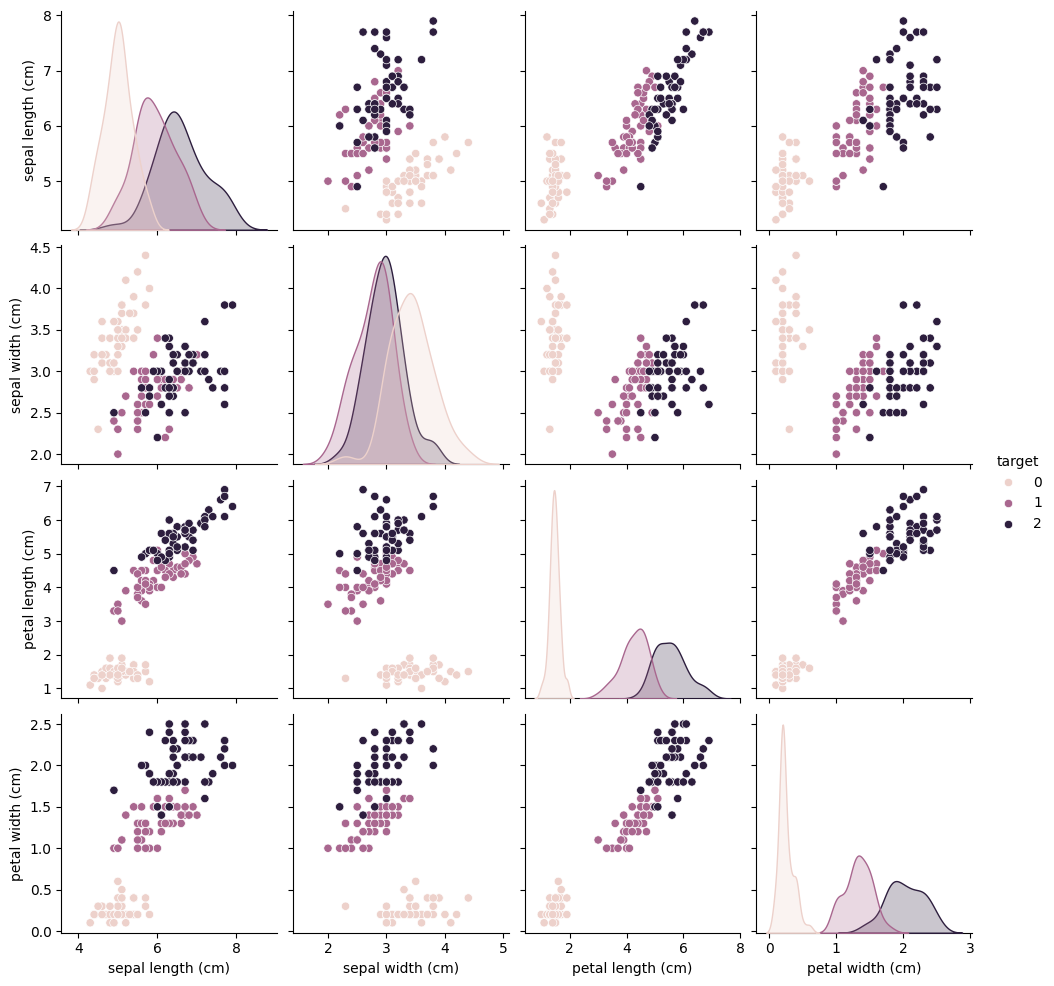

In [111]:
sns.pairplot(iris_df,hue='target')
plt.show()

In [49]:
x = iris.data # 특성 배열(2d array)
y = iris.target # 타겟, 레이블 배열(1d array)

In [50]:
x.shape,y.shape

((150, 4), (150,))

In [51]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [52]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [53]:
pd.Series(y).value_counts()

,count
0,50
1,50
2,50


TODO: 탐색적 데이터 탐색(시각화, countplot, histogram, pairplot, ...)

In [54]:
# 훈련 셋, 테스트 셋 나누기
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

## KNN

In [55]:
pipe=Pipeline(steps=[('scaler',StandardScaler()),('knn',KNeighborsClassifier())])

In [56]:
pipe.fit(x_train,y_train) # ML 모델 훈련

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [57]:
trainpred=pipe.predict(x_train)
trainpred # 훈련 셋 예측값

array([0, 1, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 2, 1,
       2, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [58]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[40,  0,  0],
       [ 0, 39,  1],
       [ 0,  2, 38]])

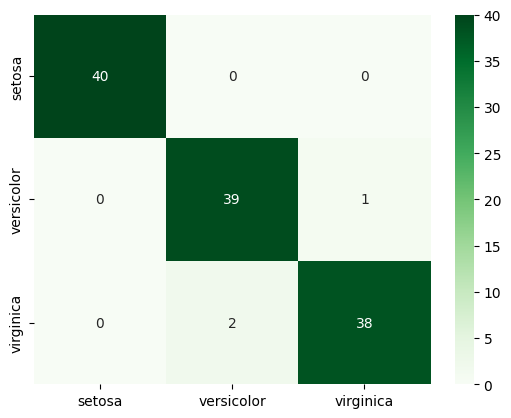

In [59]:
sns.heatmap(data=cmtrain,annot=True, cmap='Greens',
            xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.show()

In [60]:
# 훈련 셋 분류 리포트
print(classification_report(y_train,trainpred,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       0.95      0.97      0.96        40
   virginica       0.97      0.95      0.96        40

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



In [61]:
testpred=pipe.predict(x_test)

In [62]:
cmtest=confusion_matrix(y_test,testpred)
cmtest

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  2,  8]])

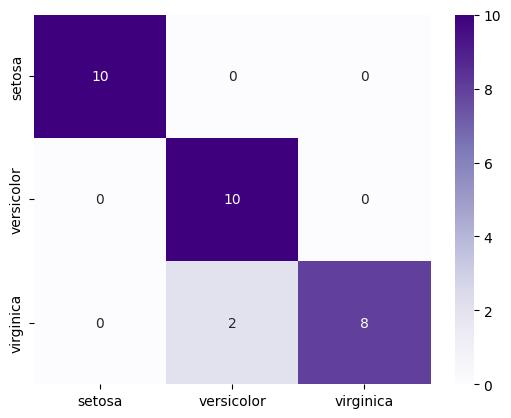

In [63]:
sns.heatmap(cmtest, annot=True, cmap='Purples',
            xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.show()

In [64]:
pipe.score(x_test,y_test), 28/30 # 테스트 셋 정확도

(0.9333333333333333, 0.9333333333333333)

In [65]:
print(classification_report(y_test,testpred,target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## LogisticRegression

In [66]:
# ML 모델 생성
logi=LogisticRegression(random_state=42,penalty='l2',C=(1/0.0001),max_iter=1000,tol=0.001)

In [67]:
logi.fit(x_train,y_train)

LogisticRegression(C=10000.0, max_iter=1000, random_state=42, tol=0.001)

In [68]:
31096-2267-25529

3300

In [69]:
# ML 모델 훈련
logi.fit(x_train,y_train)

LogisticRegression(C=10000.0, max_iter=1000, random_state=42, tol=0.001)

In [70]:
# LogisticRegression 알고리즘이 (찾은 모델 파라미터들) 데이터를 학습하고 찾은 모델 파라미터들
logi.coef_ # shape(3,4) =(n_samples(classes),n_features)

array([[  5.60921302,  16.08296718, -24.20363691, -11.13427071],
       [ -2.11164606,  -4.67919125,   8.08153865,  -3.02012828],
       [ -3.49756696, -11.40377593,  16.12209826,  14.15439899]])

In [71]:
# 훈련 셋 예측값
trainpred=logi.predict(x_train)

In [72]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[40,  0,  0],
       [ 0, 39,  1],
       [ 0,  1, 39]])

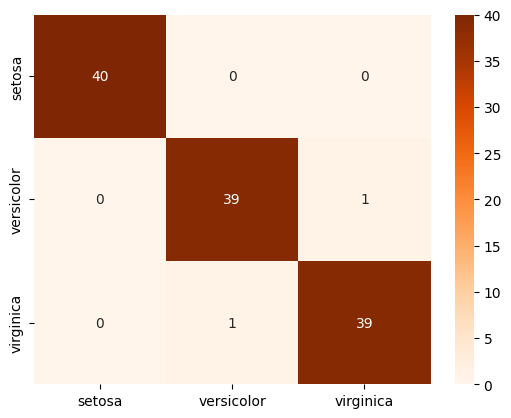

In [73]:
sns.heatmap(cmtrain, annot=True, cmap='Oranges',
            xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.show()

In [74]:
# 훈련 셋 정확도(accuracy)
logi.score(x_train,y_train), 118/120

(0.9833333333333333, 0.9833333333333333)

In [75]:
# 테스트 셋 정확도
logi.score(x_test,y_test) # 과소적합(under-fitting)

1.0

In [76]:
testpred=logi.predict(x_test)
testpred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [77]:
cmtest=confusion_matrix(y_test,testpred)
cmtest

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

## SGD Classifier

In [78]:
# SGD 분류 모델 생성
sgd=SGDClassifier(loss='log_loss',random_state=42)

In [79]:
# 모델 훈련
sgd.fit(x_train,y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [80]:
# SGD 알고리즘이 데이터를 학습하고 찾은 모델 파라미터
sgd.coef_

array([[  0.81566263,  25.82925602, -35.34529579, -17.94453494],
       [  9.53117475, -81.8318055 ,  48.80621668, -93.58400037],
       [-82.51463323, -76.6565303 , 167.53048437, 139.5525432 ]])

In [81]:
# 훈련 셋 예측값
trainpred=sgd.predict(x_train)
trainpred

array([0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 2, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 2, 0, 2, 2, 1, 2, 2, 2, 0, 1, 0, 2,
       0, 0, 2, 0, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 1,
       2, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 0, 1, 2, 1, 2, 1,
       0, 2, 1, 2, 0, 0, 0, 0, 2, 0])

In [82]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain # 잘못잡으면 여러가지추가 poly, standard ,...

array([[39,  1,  0],
       [ 0, 18, 22],
       [ 0,  0, 40]])

In [83]:
sgd.score(x_train,y_train)

0.8083333333333333

In [84]:
# 테스트 셋 예측값
testpred=sgd.predict(x_test)
testpred

array([0, 2, 1, 1, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [85]:
cmtest=confusion_matrix(y_test,testpred)
cmtest

array([[10,  0,  0],
       [ 0,  5,  5],
       [ 0,  0, 10]])

In [86]:
sgd.score(x_test,y_test)

0.8333333333333334

## Pipeline: poly > scaler > sgd

In [87]:
pipe=Pipeline(steps=[('poly',PolynomialFeatures(include_bias=False)),('scaler',StandardScaler()),('sgd',SGDClassifier(random_state=42,loss='log_loss'))])
                                            #include가 있으면 coef_ 맨앞에 0이들어감

In [88]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('sgd', SGDClassifier(loss='log_loss', random_state=42))])

In [89]:
trainpred=pipe.predict(x_train)
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[40,  0,  0],
       [ 0, 39,  1],
       [ 0,  1, 39]])

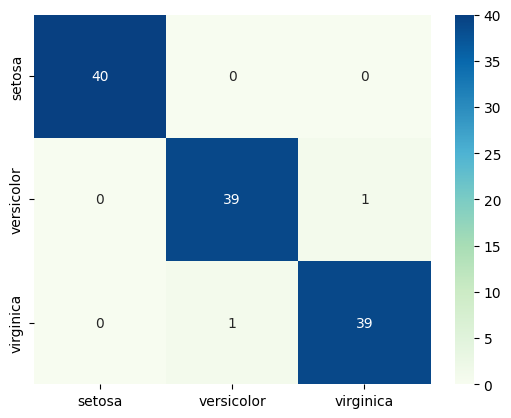

In [90]:
sns.heatmap(cmtrain,cmap='GnBu',annot=True,xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.show()

In [91]:
# SGD가 데이터 학습에서 찾은 모델 파라미터들
pipe['sgd'].coef_

array([[ -8.72662917,  15.3888124 , -17.17129504, -12.89675797,
         -6.13778489,   5.7896762 , -11.35053896,  -8.69921271,
         14.72074179, -10.64195527,  -8.30387179,  -8.79448518,
         -5.87251399,  -3.04574954],
       [ 17.04154473,  -9.17860438,  26.90024674,  30.03325052,
         -5.04297184,   0.53027908,  -5.29183516,   2.15300088,
        -13.06321139,  28.79314316,  34.52194868, -39.75545261,
        -37.1807055 , -39.16885879],
       [ -7.96405092,  -7.64679071,  12.37802805,  10.78312611,
         -0.72179762,  -3.64045192,  11.79877317,   8.9911483 ,
         -6.2010562 ,   8.98286177,   4.68496925,  21.70366288,
         19.32293484,  18.54047653]])

In [92]:
pipe.score(x_train,y_train) # 훈련 셋 정확도

0.9833333333333333

In [93]:
pipe.score(x_test,y_test) # 테스트 셋 정확도

1.0

In [94]:
testpred=pipe.predict(x_test)
cmtest=confusion_matrix(y_test,testpred)
cmtest

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

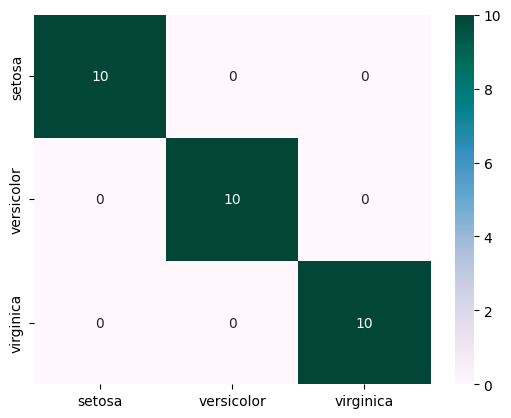

In [95]:
sns.heatmap(cmtest,cmap='PuBuGn',annot=True,xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.show()

### SGD의 손실 함수 변경

In [96]:
sgd=SGDClassifier(random_state=42) # loss='hinge' 기본값

In [97]:
sgd.fit(x_train,y_train)

SGDClassifier(random_state=42)

In [98]:
trainpred=sgd.predict(x_train)
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[40,  0,  0],
       [12,  7, 21],
       [ 0,  0, 40]])

In [99]:
sgd.score(x_train,y_train)

0.725

In [100]:
sgd.score(x_test,y_test)

0.7666666666666667

In [113]:
np.where([[True, False], [True, True]],
...          [[1, 2], [3, 4]],
...          [[9, 8], [7, 6]])

array([[1, 8],
       [3, 4]])

In [118]:
a=np.arange(0,10).reshape(2,5)
a

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])